<a href="https://colab.research.google.com/github/SalmanOkz/computer_vision/blob/main/complete_lab_manual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

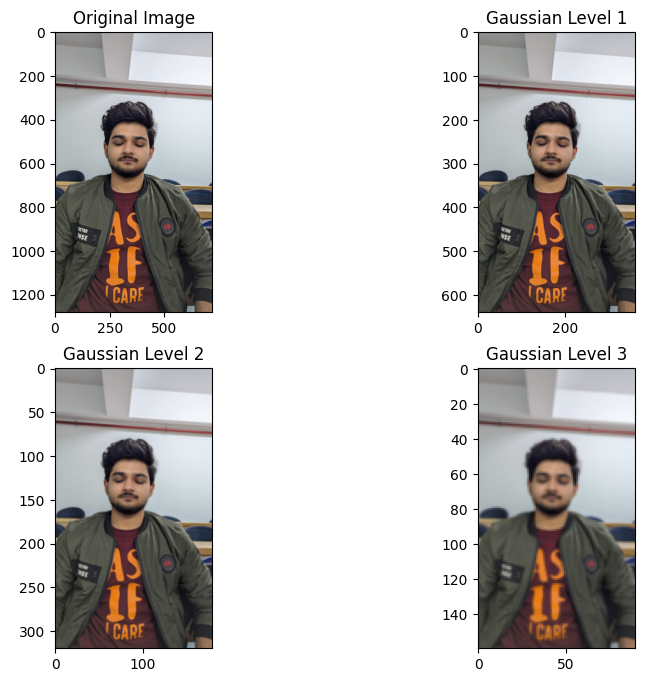

In [ ]:
import cv2
from matplotlib import pyplot as plt

# Load original image
image = cv2.imread('/content/WhatsApp Image 2026-01-06 at 3.57.53 PM (1).jpeg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Generate Gaussian Pyramid
gp1 = cv2.pyrDown(image)
gp2 = cv2.pyrDown(gp1)
gp3 = cv2.pyrDown(gp2)

# Display
plt.figure(figsize=(10, 8))
plt.subplot(2, 2, 1)
plt.imshow(image)
plt.title('Original Image')

plt.subplot(2, 2, 2)
plt.imshow(gp1)
plt.title('Gaussian Level 1')

plt.subplot(2, 2, 3)
plt.imshow(gp2)
plt.title('Gaussian Level 2')

plt.subplot(2, 2, 4)
plt.imshow(gp3)
plt.title('Gaussian Level 3')

plt.show()


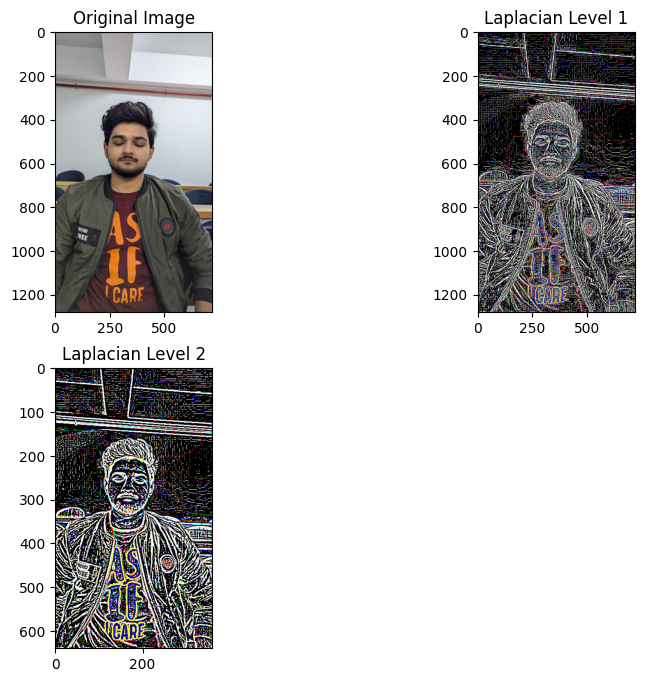

In [ ]:
import cv2
from matplotlib import pyplot as plt

# Load and convert the image
image = cv2.imread('/content/WhatsApp Image 2026-01-06 at 3.57.53 PM (1).jpeg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Gaussian Pyramid Levels
gp1 = cv2.pyrDown(image)
gp2 = cv2.pyrDown(gp1)

# Laplacian Levels
lp1 = image - cv2.pyrUp(gp1)[:image.shape[0], :image.shape[1]]  # Crop to match original image size
pyrUp_gp2 = cv2.pyrUp(gp2)
lp2 = gp1 - pyrUp_gp2[:gp1.shape[0], :gp1.shape[1]]  # Crop to match gp1 size

# Display Results
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(image)
plt.title('Original Image')

plt.subplot(2, 2, 2)
plt.imshow(lp1)
plt.title('Laplacian Level 1')

plt.subplot(2, 2, 3)
plt.imshow(lp2)
plt.title('Laplacian Level 2')

plt.show()


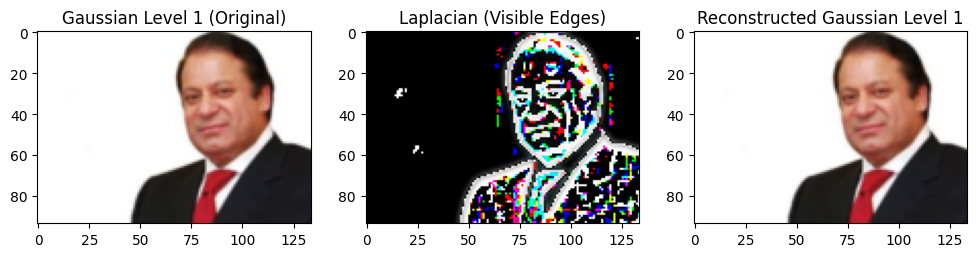

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load image
image = cv2.imread('/content/theif.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Gaussian Pyramid
gp1 = cv2.pyrDown(image)  # First level of Gaussian pyramid
gp2 = cv2.pyrDown(gp1)   # Second level of Gaussian pyramid

# Laplacian Calculation
gp2_up = cv2.pyrUp(gp2)  # Upsample gp2 to match gp1's size
gp2_up = cv2.resize(gp2_up, (gp1.shape[1], gp1.shape[0]))  # Ensure dimensions match
lap = gp1 - gp2_up  # Laplacian = difference between gp1 and upsampled gp2

# Reconstruction
# Reconstruct gp1 by adding the Laplacian (lap) to the upsampled gp2 (gp2_up)
reconstructed = gp2_up + lap

# Display Results
plt.figure(figsize=(12, 8))

plt.subplot(1, 3, 1)
plt.imshow(gp1)
plt.title("Gaussian Level 1 (Original)")

plt.subplot(1, 3, 2)
plt.imshow(lap)
plt.title("Laplacian (Visible Edges)")

plt.subplot(1, 3, 3)
plt.imshow(reconstructed)
plt.title("Reconstructed Gaussian Level 1")

plt.show()


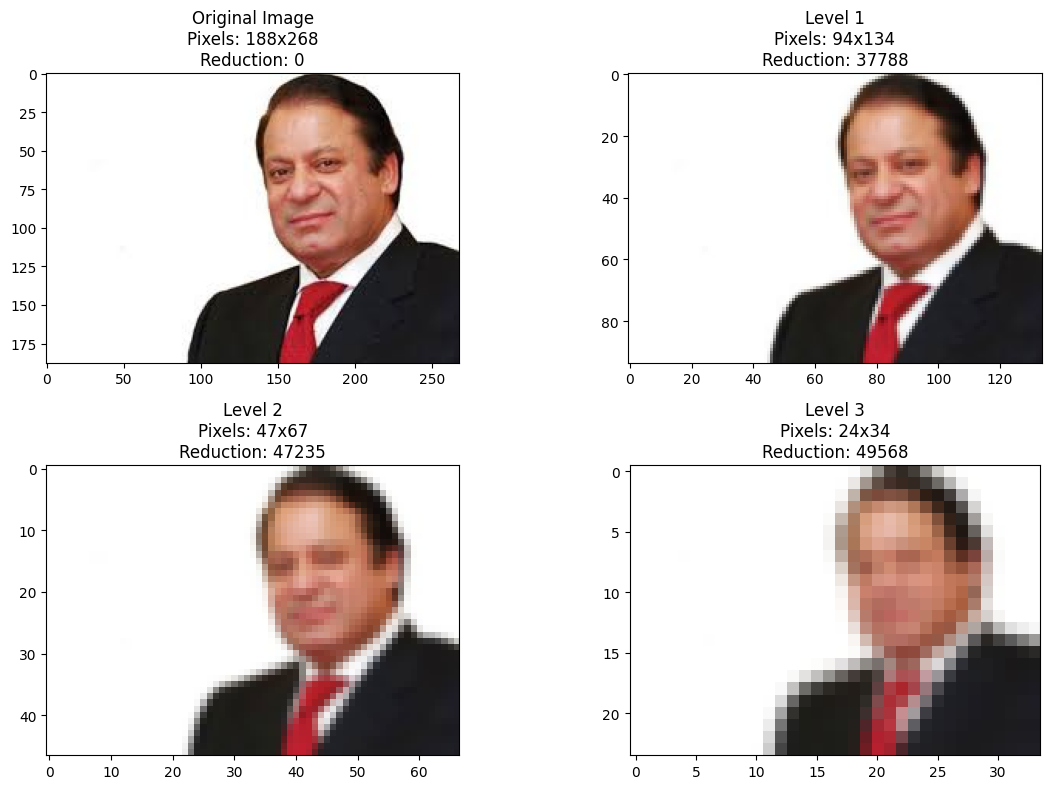

Pixel Reduction Summary:
Level 1: 37788 pixels reduced
Level 2: 47235 pixels reduced
Level 3: 49568 pixels reduced


In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load the image
image_path = '/content/theif.jpg'  # Replace with your image path
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB for display

# Generate the four-level Gaussian Pyramid
gaussian_pyramid = [image]
for _ in range(3):  # 3 downsamples to get 4 levels total
    gaussian_pyramid.append(cv2.pyrDown(gaussian_pyramid[-1]))

# Calculate pixel reduction for each level
original_pixels = image.shape[0] * image.shape[1]
pixel_reductions = []
for level in gaussian_pyramid[1:]:
    current_pixels = level.shape[0] * level.shape[1]
    reduction = original_pixels - current_pixels
    pixel_reductions.append(reduction)

# Display the pyramid and pixel reductions
plt.figure(figsize=(12, 8))
titles = ['Original Image', 'Level 1', 'Level 2', 'Level 3']
for i, (img, title) in enumerate(zip(gaussian_pyramid, titles)):
    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(f"{title}\nPixels: {img.shape[0]}x{img.shape[1]}\nReduction: {pixel_reductions[i-1] if i > 0 else 0}")

plt.tight_layout()
plt.show()

# Print pixel reduction summary
print("Pixel Reduction Summary:")
for i, reduction in enumerate(pixel_reductions, start=1):
    print(f"Level {i}: {reduction} pixels reduced")


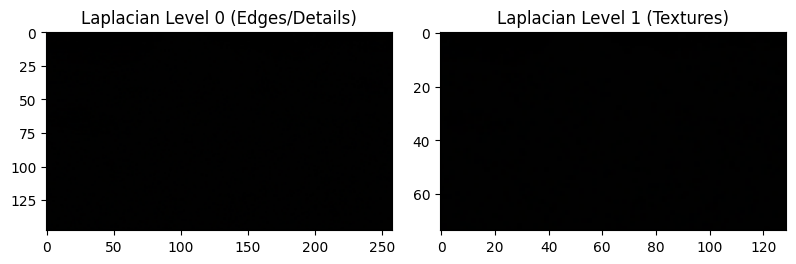

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path = '/content/pahar.jpg'  # Replace with your image path
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB

# Generate Gaussian Pyramid (3 levels)
gaussian_pyramid = [image]
for _ in range(2):  # 2 downsamples to get 3 levels total
    gaussian_pyramid.append(cv2.pyrDown(gaussian_pyramid[-1]))

# Generate Laplacian Pyramid
laplacian_pyramid = []
for i in range(len(gaussian_pyramid) - 1):
    # Upsample the smaller Gaussian level
    upsampled = cv2.pyrUp(gaussian_pyramid[i + 1])
    # Resize to match the current Gaussian level's dimensions
    upsampled = cv2.resize(upsampled, (gaussian_pyramid[i].shape[1], gaussian_pyramid[i].shape[0]))
    # Laplacian level = current Gaussian level - upsampled smaller Gaussian level
    laplacian_level = gaussian_pyramid[i] - upsampled
    laplacian_pyramid.append(laplacian_level)

# The smallest Gaussian level is the last level
laplacian_pyramid.append(gaussian_pyramid[-1])  # Add the smallest Gaussian level as the last Laplacian level

# Display the Laplacian Pyramid
plt.figure(figsize=(12, 8))
titles = ['Laplacian Level 0 (Edges/Details)', 'Laplacian Level 1 (Textures)', 'Laplacian Level 2 (Coarse Details)']
for i, (lap_level, title) in enumerate(zip(laplacian_pyramid[:-1], titles)):
    plt.subplot(1, 3, i+1)
    plt.imshow(np.clip(lap_level, 0, 1))  # Clip to visualize details
    plt.title(title)

plt.tight_layout()
plt.show()


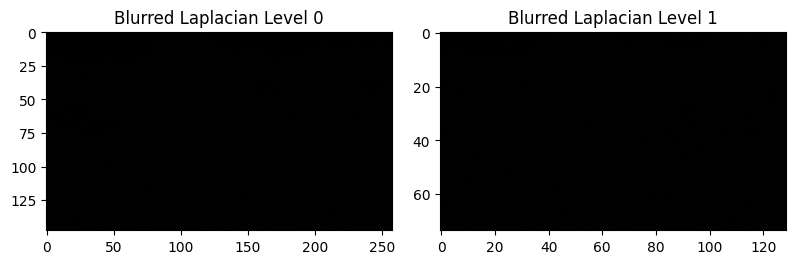

In [ ]:
# Blur the smallest Gaussian level
blurred_gaussian = cv2.GaussianBlur(gaussian_pyramid[-1], (5, 5), 0)

# Reconstruct the Laplacian Pyramid with blurred smallest level
laplacian_pyramid_blurred = []
for i in range(len(gaussian_pyramid) - 1):
    upsampled = cv2.pyrUp(gaussian_pyramid[i + 1] if i < len(gaussian_pyramid) - 2 else blurred_gaussian)
    upsampled = cv2.resize(upsampled, (gaussian_pyramid[i].shape[1], gaussian_pyramid[i].shape[0]))
    laplacian_level = gaussian_pyramid[i] - upsampled
    laplacian_pyramid_blurred.append(laplacian_level)

laplacian_pyramid_blurred.append(blurred_gaussian)  # Add blurred smallest level

# Display the blurred Laplacian Pyramid
plt.figure(figsize=(12, 8))
titles = ['Blurred Laplacian Level 0', 'Blurred Laplacian Level 1', 'Blurred Laplacian Level 2']
for i, (lap_level, title) in enumerate(zip(laplacian_pyramid_blurred[:-1], titles)):
    plt.subplot(1, 3, i+1)
    plt.imshow(np.clip(lap_level, 0, 1))
    plt.title(title)

plt.tight_layout()
plt.show()


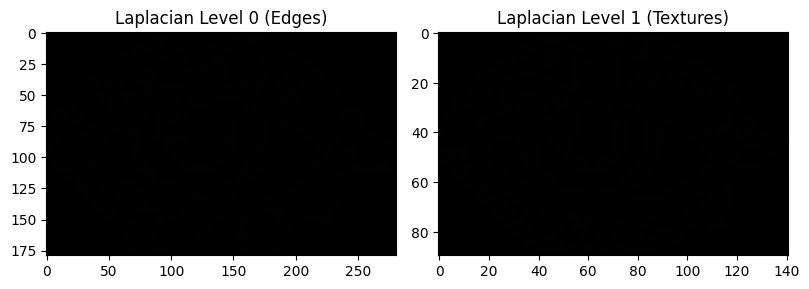

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load your image (replace with your image path)
image = cv2.imread('/content/download.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB

# Generate Gaussian Pyramid (3 levels)
gaussian_pyramid = [image]
for _ in range(2):  # 2 downsamples to get 3 levels
    gaussian_pyramid.append(cv2.pyrDown(gaussian_pyramid[-1]))

# Generate Laplacian Pyramid
laplacian_pyramid = []
for i in range(len(gaussian_pyramid) - 1):
    # Upsample the smaller Gaussian level
    upsampled = cv2.pyrUp(gaussian_pyramid[i + 1])
    # Resize to match dimensions
    upsampled = cv2.resize(upsampled, (gaussian_pyramid[i].shape[1], gaussian_pyramid[i].shape[0]))
    # Laplacian level = current Gaussian - upsampled smaller Gaussian
    laplacian_level = gaussian_pyramid[i] - upsampled
    laplacian_pyramid.append(laplacian_level)

# The smallest Gaussian level is the last level
laplacian_pyramid.append(gaussian_pyramid[-1])

# Display the Laplacian Pyramid
plt.figure(figsize=(12, 8))
titles = ['Laplacian Level 0 (Edges)', 'Laplacian Level 1 (Textures)', 'Laplacian Level 2 (Coarse Details)']
for i, (lap_level, title) in enumerate(zip(laplacian_pyramid[:-1], titles)):
    plt.subplot(1, 3, i+1)
    plt.imshow(np.clip(lap_level, 0, 1))  # Clip for visualization
    plt.title(title)

plt.tight_layout()
plt.show()


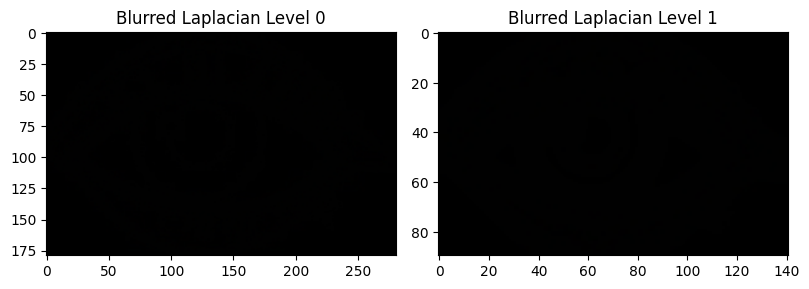

In [ ]:
# Blur the smallest Gaussian level
blurred_gaussian = cv2.GaussianBlur(gaussian_pyramid[-1], (5, 5), 0)

# Reconstruct Laplacian Pyramid with blurred smallest level
laplacian_pyramid_blurred = []
for i in range(len(gaussian_pyramid) - 1):
    upsampled = cv2.pyrUp(gaussian_pyramid[i + 1] if i < len(gaussian_pyramid) - 2 else blurred_gaussian)
    upsampled = cv2.resize(upsampled, (gaussian_pyramid[i].shape[1], gaussian_pyramid[i].shape[0]))
    laplacian_level = gaussian_pyramid[i] - upsampled
    laplacian_pyramid_blurred.append(laplacian_level)

laplacian_pyramid_blurred.append(blurred_gaussian)  # Add blurred smallest level

# Display the blurred Laplacian Pyramid
plt.figure(figsize=(12, 8))
titles = ['Blurred Laplacian Level 0', 'Blurred Laplacian Level 1', 'Blurred Laplacian Level 2']
for i, (lap_level, title) in enumerate(zip(laplacian_pyramid_blurred[:-1], titles)):
    plt.subplot(1, 3, i+1)
    plt.imshow(np.clip(lap_level, 0, 1))
    plt.title(title)

plt.tight_layout()
plt.show()


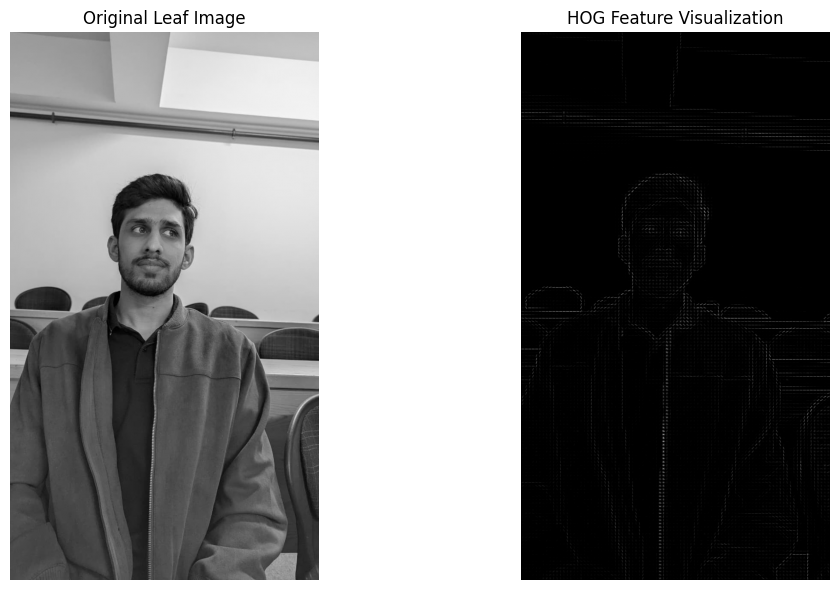

In [ ]:
import cv2
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure
from zipfile import ZipFile
import numpy as np
from io import BytesIO
from PIL import Image

# Path to your zip file
zip_path = '/content/dataset.zip'

# Open the zip file and read the first JPG image
with ZipFile(zip_path, 'r') as zip_ref:
    # List all files in the zip
    file_list = zip_ref.namelist()

    # Find the first JPG or JPEG image
    img_file = next((f for f in file_list if f.lower().endswith(('.jpg', '.jpeg'))), None)
    if img_file is None:
        raise ValueError("No JPG or JPEG image found in the zip file.")

    # Read the image data into memory
    with zip_ref.open(img_file) as file:
        img = Image.open(BytesIO(file.read())).convert('L')  # Convert to grayscale
        img_leaf = np.array(img)

# Compute HOG features
hog_features, hog_image = hog(
    img_leaf,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    visualize=True,
    block_norm='L2-Hys'
)

# Rescale HOG image for better visibility
hog_image_rescaled = exposure.rescale_intensity(
    hog_image,
    in_range=(hog_image.min(), hog_image.max())
)

# Display the original image and HOG visualization
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_leaf, cmap='gray')
plt.title("Original Leaf Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hog_image_rescaled, cmap='gray')
plt.title("HOG Feature Visualization")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras import datasets, models, layers
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
(X_train,y_train),(X_test,y_test)=datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# reshap size
X_train=X_train.reshape((-1,28,28,1))
X_test=X_test.reshape((-1,28,28,1))

In [ ]:
model = models.Sequential([
    # Conv Layer with padding='same' (preserve input size)
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    # MaxPooling layer (reduces feature map size)
    layers.MaxPooling2D(pool_size=(2,2)),

    # Second Conv Layer
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2,2)),

    # Flatten to 1D
    layers.Flatten(),
    # Fully Connected Layer
    layers.Dense(64, activation='relu'),
    # Output Layer
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(X_train, y_train, epochs=2,
                    validation_data=(X_test, y_test))


test_loss, test_acc = model.evaluate(X_test, y_test)

Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 110s 58ms/step - accuracy: 0.7944 - loss: 1.1053 - val_accuracy: 0.8814 - val_loss: 0.3379
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 44ms/step - accuracy: 0.8953 - loss: 0.2892 - val_accuracy: 0.8860 - val_loss: 0.3204
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8859 - loss: 0.3247


In [ ]:
plt.figure(figsize=(10, 8))
plt.subplot(1,2,1)
plt.plot(history.history[''])

Panorama created successfully!


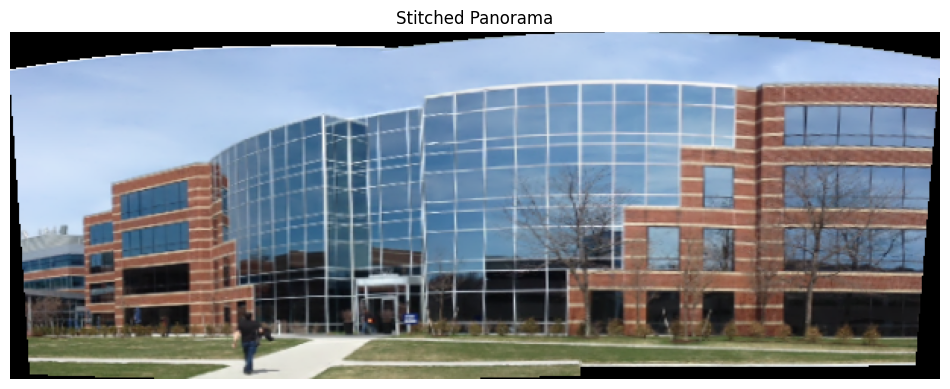

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load images (replace with your image paths)
image_paths = ['/content/Screenshot 2026-01-22 235743.png', '/content/Screenshot 2026-01-22 235749.png', '/content/Screenshot 2026-01-22 235755.png']
images = [cv2.imread(path) for path in image_paths]

# Initialize OpenCV Stitcher
stitcher = cv2.Stitcher_create()

# Stitch images
status, panorama = stitcher.stitch(images)

if status == cv2.Stitcher_OK:
    # Save the panorama
    cv2.imwrite('panorama_output.jpg', panorama)
    print("Panorama created successfully!")

    # Display the panorama
    plt.figure(figsize=(12, 6))
    plt.imshow(cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Stitched Panorama')
    plt.show()
else:
    print(f"Stitching failed with status: {status}")


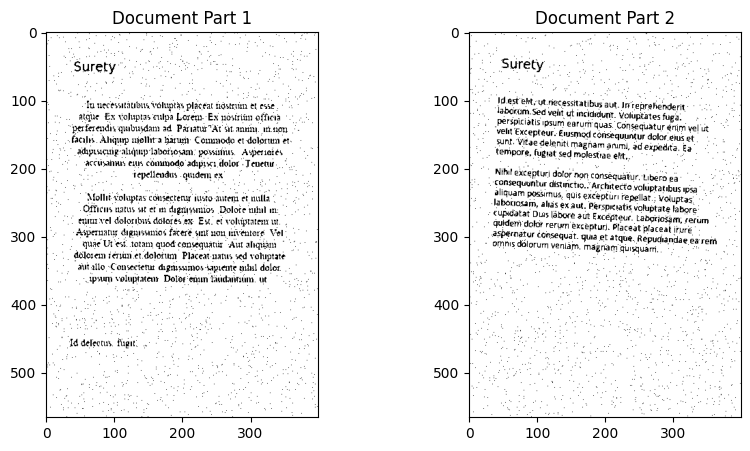

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load images
img1 = cv2.imread('/content/scan_000.png', cv2.IMREAD_GRAYSCALE)  # Left part
img2 = cv2.imread('/content/scan_001.png', cv2.IMREAD_GRAYSCALE)  # Right part

# Display images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img1, cmap='gray')
plt.title('Document Part 1')
plt.subplot(1, 2, 2)
plt.imshow(img2, cmap='gray')
plt.title('Document Part 2')
plt.show()


Original image dimensions: 210 x 240
Scaled image dimensions: 1050 x 1200


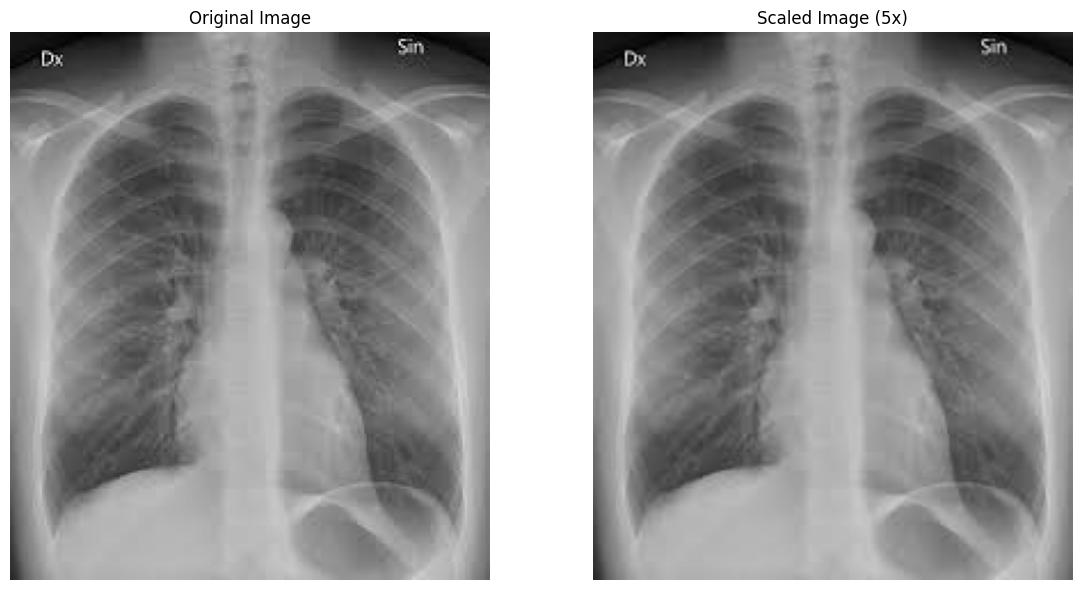

In [29]:
import cv2
import matplotlib.pyplot as plt

# Load the X-ray image
img = cv2.imread('/content/x-ray.jpg')

# Convert from BGR to RGB for correct display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Scale the image by a factor of 5 using linear interpolation
scaled_img = cv2.resize(img_rgb, None, fx=5, fy=5, interpolation=cv2.INTER_LINEAR)

# Print the dimensions of the original and scaled images
print(f"Original image dimensions: {img_rgb.shape[1]} x {img_rgb.shape[0]}")
print(f"Scaled image dimensions: {scaled_img.shape[1]} x {scaled_img.shape[0]}")

# Display the original and scaled images side-by-side
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Scaled Image (5x)')
plt.imshow(scaled_img)
plt.axis('off')

plt.tight_layout()
plt.show()


Original Resolution: Width=268, Height=188
New Canvas Resolution after Translation: Width=348, Height=238


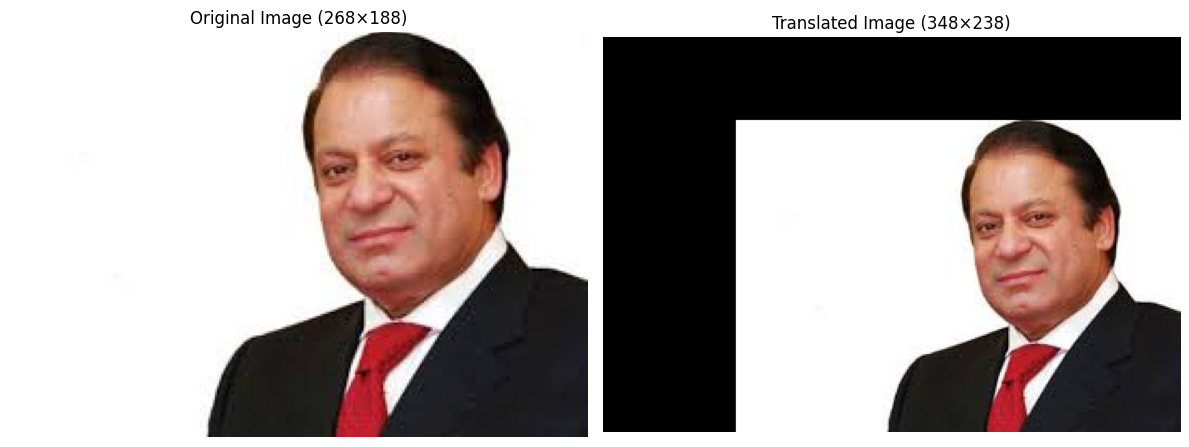

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
img = cv2.imread('/content/theif.jpg')

# Convert from BGR to RGB for correct display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Get original image dimensions
h, w = img.shape[:2]
print(f"Original Resolution: Width={w}, Height={h}")

# Define translation values (shift right by 80 pixels, shift down by 50 pixels)
tx, ty = 80, 50

# Create the translation matrix
M = np.float32([[1, 0, tx],
                [0, 1, ty]])

# Calculate new canvas size to avoid cropping
new_w = w + tx
new_h = h + ty
print(f"New Canvas Resolution after Translation: Width={new_w}, Height={new_h}")

# Apply the translation
translated = cv2.warpAffine(img_rgb, M, (new_w, new_h))

# Visualize the original and translated images
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title(f'Original Image ({w}×{h})')
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f'Translated Image ({new_w}×{new_h})')
plt.imshow(translated)
plt.axis('off')

plt.tight_layout()
plt.show()


Rotation Center Coordinates: (200, 283)


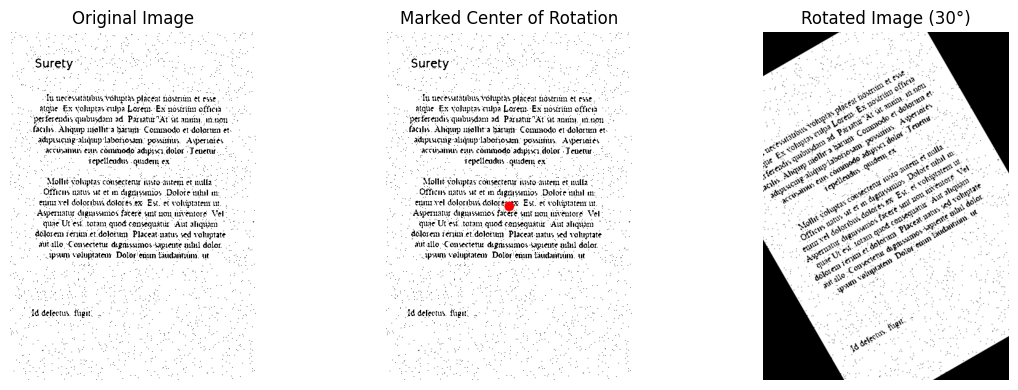

In [31]:
import cv2
import matplotlib.pyplot as plt

# Load the image
img = cv2.imread('/content/scan_000.png')

# Convert from BGR to RGB for correct display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Get image dimensions
h, w = img.shape[:2]

# Define the center of rotation
center = (w // 2, h // 2)
print(f"Rotation Center Coordinates: {center}")

# Mark the center on the image
marked_img = img_rgb.copy()
cv2.circle(marked_img, center, radius=8, color=(255, 0, 0), thickness=-1)

# Create the rotation matrix
# Arguments: center of rotation, angle in degrees, scale factor
M = cv2.getRotationMatrix2D(center, 30, 1.0)

# Apply the rotation
rotated = cv2.warpAffine(img_rgb, M, (w, h))

# Display the results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Marked Center of Rotation')
plt.imshow(marked_img)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Rotated Image (30°)')
plt.imshow(rotated)
plt.axis('off')

plt.tight_layout()
plt.show()


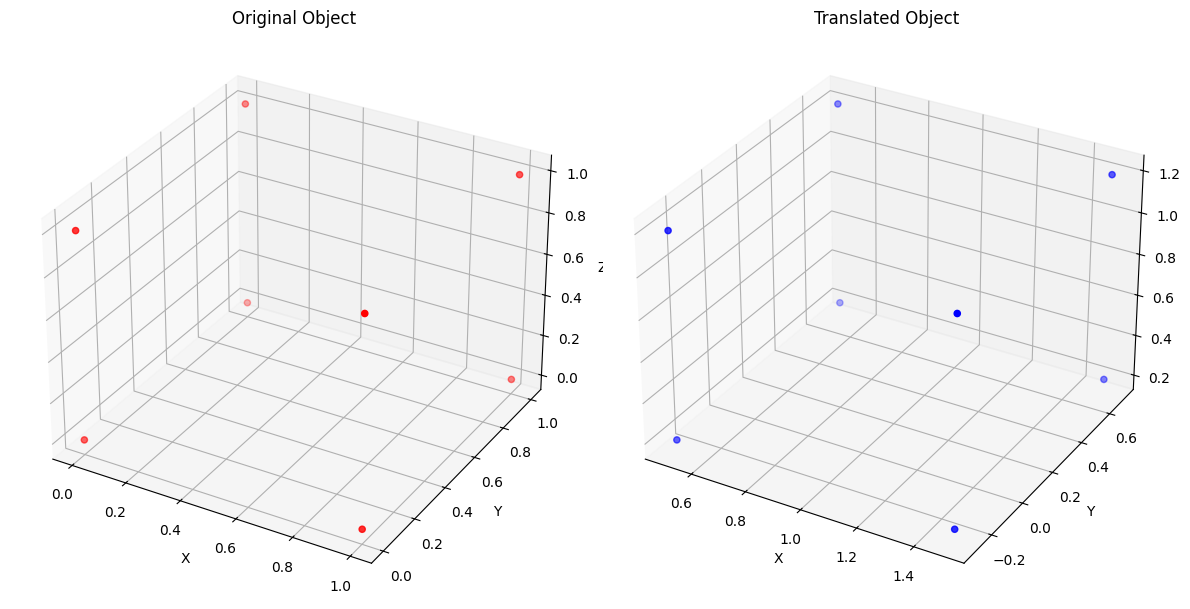

Applied Translation: tx=0.5, ty=-0.3, tz=0.2


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Simulate 3D points of an object (e.g., a cube)
points = np.array([
    [0, 0, 0], [1, 0, 0], [1, 1, 0], [0, 1, 0],  # Bottom face
    [0, 0, 1], [1, 0, 1], [1, 1, 1], [0, 1, 1]   # Top face
])

# Define translation values (x, y, z)
tx, ty, tz = 0.5, -0.3, 0.2  # Example: Wind gusts misaligned the object

# Create the 4x4 translation matrix
translation_matrix = np.array([
    [1, 0, 0, tx],
    [0, 1, 0, ty],
    [0, 0, 1, tz],
    [0, 0, 0, 1]
])

# Convert points to homogeneous coordinates (add 1 as the 4th coordinate)
homogeneous_points = np.hstack((points, np.ones((points.shape[0], 1))))

# Apply translation
translated_points = (translation_matrix @ homogeneous_points.T).T

# Extract the translated 3D points (remove the homogeneous coordinate)
translated_points = translated_points[:, :3]

# Plot the original and translated points
fig = plt.figure(figsize=(12, 6))

# Original points
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(points[:, 0], points[:, 1], points[:, 2], color='r')
ax1.set_title('Original Object')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')

# Translated points
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(translated_points[:, 0], translated_points[:, 1], translated_points[:, 2], color='b')
ax2.set_title('Translated Object')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')

plt.tight_layout()
plt.show()

# Print the translation values
print(f"Applied Translation: tx={tx}, ty={ty}, tz={tz}")


In [34]:
!pip install open3d


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.8 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1


In [35]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt

# Generate a sample point cloud (e.g., a cube)
points = np.array([
    [0, 0, 0], [1, 0, 0], [1, 1, 0], [0, 1, 0],  # Bottom face
    [0, 0, 1], [1, 0, 1], [1, 1, 1], [0, 1, 1]   # Top face
])

# Convert to Open3D point cloud for visualization
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)


In [36]:
# Define translation values
tx, ty, tz = 0.5, -0.3, 0.2  # Example translation


In [37]:
# Create the 4x4 translation matrix
translation_matrix = np.array([
    [1, 0, 0, tx],
    [0, 1, 0, ty],
    [0, 0, 1, tz],
    [0, 0, 0, 1]
])


In [38]:
# Convert points to homogeneous coordinates
homogeneous_points = np.hstack((points, np.ones((points.shape[0], 1))))

# Apply translation
translated_points_h = (translation_matrix @ homogeneous_points.T).T

# Extract the translated 3D points (remove the homogeneous coordinate)
translated_points = translated_points_h[:, :3]


In [39]:
# Calculate the new bounds
min_bound = np.min(translated_points, axis=0)
max_bound = np.max(translated_points, axis=0)

print(f"New Bounds: Min={min_bound}, Max={max_bound}")


New Bounds: Min=[ 0.5 -0.3  0.2], Max=[1.5 0.7 1.2]


In [40]:
# Create Open3D point clouds for visualization
pcd_original = o3d.geometry.PointCloud()
pcd_original.points = o3d.utility.Vector3dVector(points)

pcd_translated = o3d.geometry.PointCloud()
pcd_translated.points = o3d.utility.Vector3dVector(translated_points)

# Visualize the point clouds
o3d.visualization.draw_geometries([pcd_original], window_name="Original Point Cloud")
o3d.visualization.draw_geometries([pcd_translated], window_name="Translated Point Cloud")


[Open3D WARNING] GLFW Error: Failed to detect any supported platform
[Open3D WARNING] GLFW initialized for headless rendering.
[Open3D WARNING] GLFW Error: OSMesa: Library not found
[Open3D WARNING] Failed to create window
[Open3D WARNING] [DrawGeometries] Failed creating OpenGL window.
[Open3D WARNING] GLFW initialized for headless rendering.
[Open3D WARNING] GLFW Error: OSMesa: Library not found
[Open3D WARNING] Failed to create window
[Open3D WARNING] [DrawGeometries] Failed creating OpenGL window.


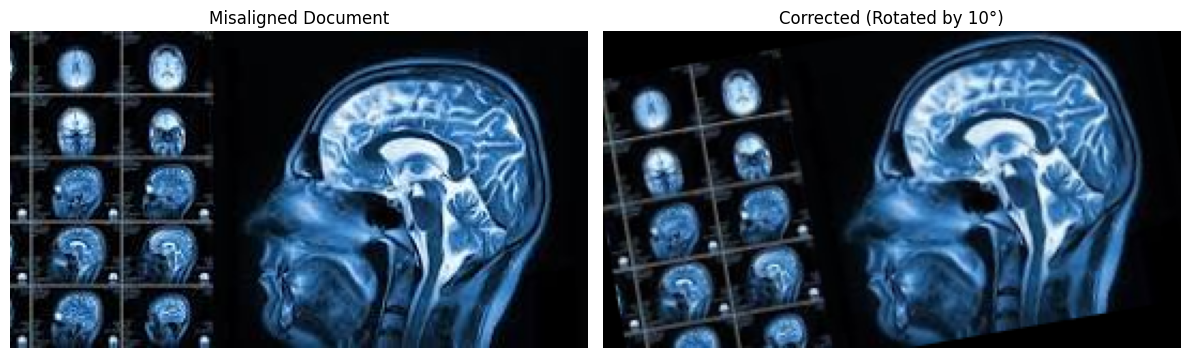

In [42]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the misaligned image
img = cv2.imread('/content/download (1).jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Get image dimensions
h, w = img.shape[:2]

# Define the center of rotation
center = (w // 2, h // 2)

# Define the rotation angle (in degrees)
angle = 10  # Adjust this value to correct misalignment

# Create the rotation matrix
M = cv2.getRotationMatrix2D(center, angle, 1.0)

# Apply the rotation
rotated = cv2.warpAffine(img_rgb, M, (w, h))

# Display the misaligned and corrected images
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Misaligned Document')
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f'Corrected (Rotated by {angle}°)')
plt.imshow(rotated)
plt.axis('off')

plt.tight_layout()
plt.show()


In [43]:
import open3d as o3d
import numpy as np

# Load or create a 3D point cloud (e.g., MRI scan)
points = np.random.rand(100, 3)  # Replace with your 3D MRI data
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)

# Define the rotation axis and angle (in radians)
axis = [0, 0, 1]  # Rotate around the z-axis
angle = np.radians(15)  # Adjust this value to correct misalignment

# Create the rotation matrix
R = pcd.get_rotation_matrix_from_axis_angle(np.array(axis) * angle)

# Apply the rotation
pcd.rotate(R, center=pcd.get_center())

# Visualize the misaligned and corrected point clouds
o3d.visualization.draw_geometries([pcd], window_name="Corrected 3D MRI Scan")


[Open3D WARNING] GLFW initialized for headless rendering.
[Open3D WARNING] GLFW Error: OSMesa: Library not found
[Open3D WARNING] Failed to create window
[Open3D WARNING] [DrawGeometries] Failed creating OpenGL window.


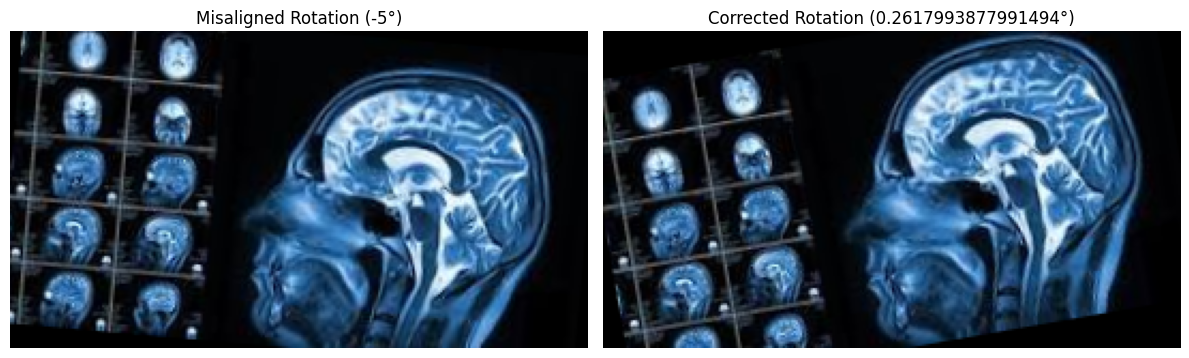

In [44]:
# Misaligned rotation (wrong angle or center)
wrong_angle = -5  # Incorrect rotation angle
M_wrong = cv2.getRotationMatrix2D(center, wrong_angle, 1.0)
misaligned_rotated = cv2.warpAffine(img_rgb, M_wrong, (w, h))

# Display the misaligned and corrected rotations
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title(f'Misaligned Rotation ({wrong_angle}°)')
plt.imshow(misaligned_rotated)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f'Corrected Rotation ({angle}°)')
plt.imshow(rotated)
plt.axis('off')

plt.tight_layout()
plt.show()


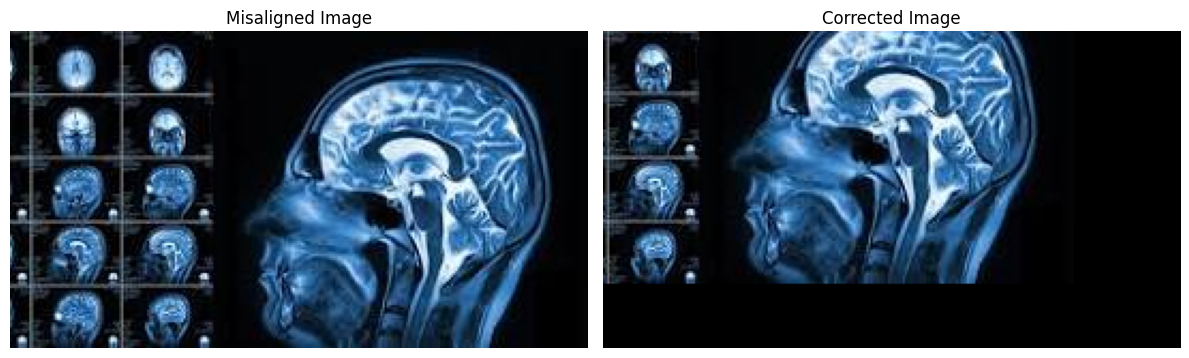

In [46]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the misaligned image
img = cv2.imread('/content/download (1).jpg') # Corrected image path
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Define translation values (e.g., shift left by 50 pixels, up by 30 pixels)
tx, ty = -50, -30

# Create the translation matrix
M = np.float32([[1, 0, tx],
                [0, 1, ty]])

# Apply translation
translated_img = cv2.warpAffine(img_rgb, M, (img.shape[1], img.shape[0]))

# Display the results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Misaligned Image')
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Corrected Image')
plt.imshow(translated_img)
plt.axis('off')

plt.tight_layout()
plt.show()

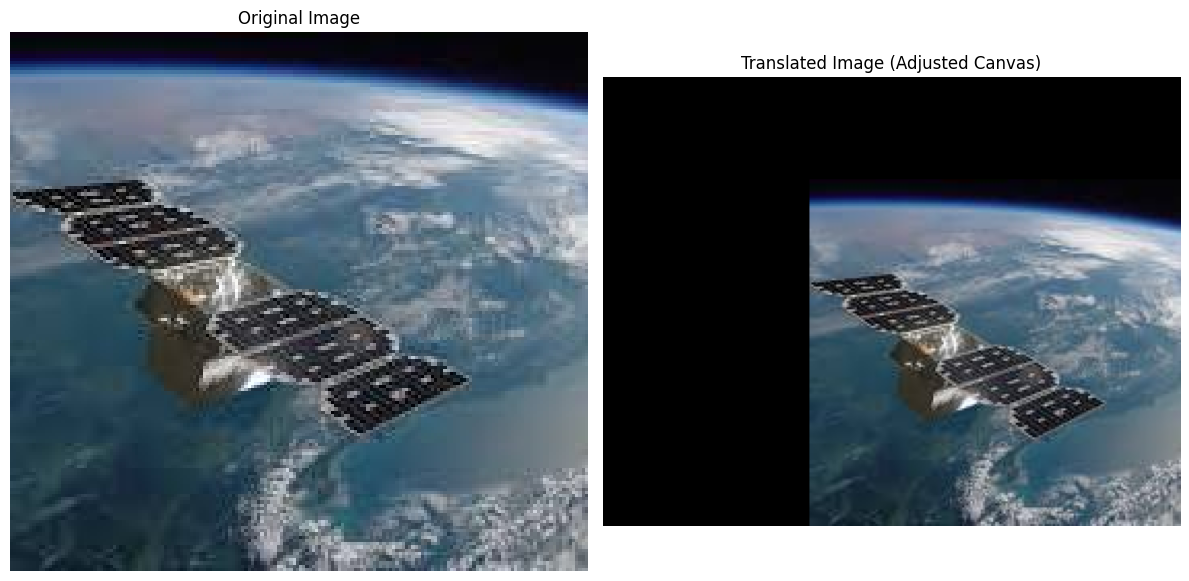

In [47]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the satellite image
img = cv2.imread('/content/set.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Define translation values (shift right by 100 pixels, down by 50 pixels)
tx, ty = 100, 50

# Create the translation matrix
M = np.float32([[1, 0, tx],
                [0, 1, ty]])

# Calculate new dimensions to avoid cropping
new_width = img.shape[1] + tx
new_height = img.shape[0] + ty

# Apply translation with adjusted canvas size
translated_img = cv2.warpAffine(img_rgb, M, (new_width, new_height))

# Display the results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Translated Image (Adjusted Canvas)')
plt.imshow(translated_img)
plt.axis('off')

plt.tight_layout()
plt.show()


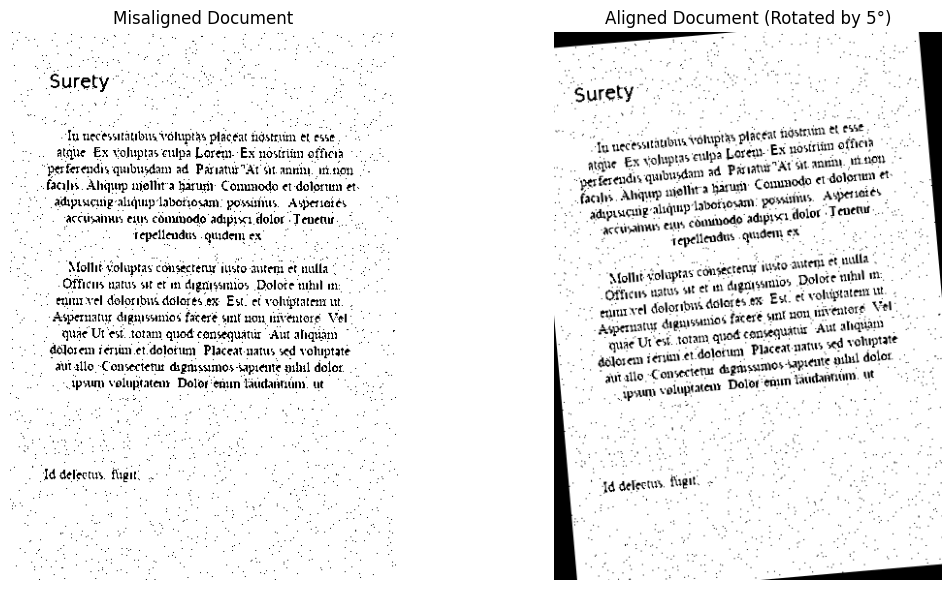

In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the misaligned document
img = cv2.imread('/content/scan_000.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Get image dimensions
h, w = img.shape[:2]

# Define the center of rotation (center of the image)
center = (w // 2, h // 2)

# Determine the rotation angle (e.g., 5 degrees clockwise)
angle = 5  # Replace with the detected skew angle

# Create the rotation matrix
M = cv2.getRotationMatrix2D(center, angle, 1.0)

# Apply the rotation
rotated = cv2.warpAffine(img_rgb, M, (w, h))

# Display the results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Misaligned Document')
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f'Aligned Document (Rotated by {angle}°)')
plt.imshow(rotated)
plt.axis('off')

plt.tight_layout()
plt.show()


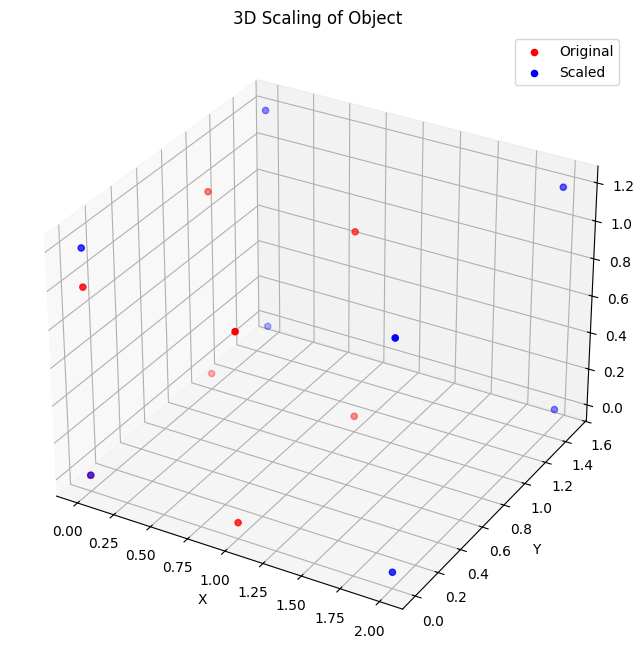

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the 3D cube points
points = np.array([
    [0, 0, 0], [1, 0, 0], [1, 1, 0], [0, 1, 0],  # Bottom face
    [0, 0, 1], [1, 0, 1], [1, 1, 1], [0, 1, 1]   # Top face
])

# Function to scale 3D points
def scale(points, sx, sy, sz):
    # Define the 4x4 scaling matrix
    S = np.array([
        [sx, 0, 0, 0],
        [0, sy, 0, 0],
        [0, 0, sz, 0],
        [0, 0, 0, 1]
    ])

    # Convert points to homogeneous coordinates
    points_h = np.hstack((points, np.ones((points.shape[0], 1))))

    # Apply scaling transformation
    scaled_points_h = (S @ points_h.T).T

    # Return only the x, y, z coordinates (remove homogeneous coordinate)
    return scaled_points_h[:, :3]

# Scale the cube by factors of 2, 1.5, and 1.2 along x, y, and z axes
scaled_points = scale(points, 2, 1.5, 1.2)

# Plot the original and scaled cubes
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot original cube
ax.scatter(points[:, 0], points[:, 1], points[:, 2], color='r', label='Original')

# Plot scaled cube
ax.scatter(scaled_points[:, 0], scaled_points[:, 1], scaled_points[:, 2], color='b', label='Scaled')

# Add labels and title
ax.set_title("3D Scaling of Object")
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()

plt.show()


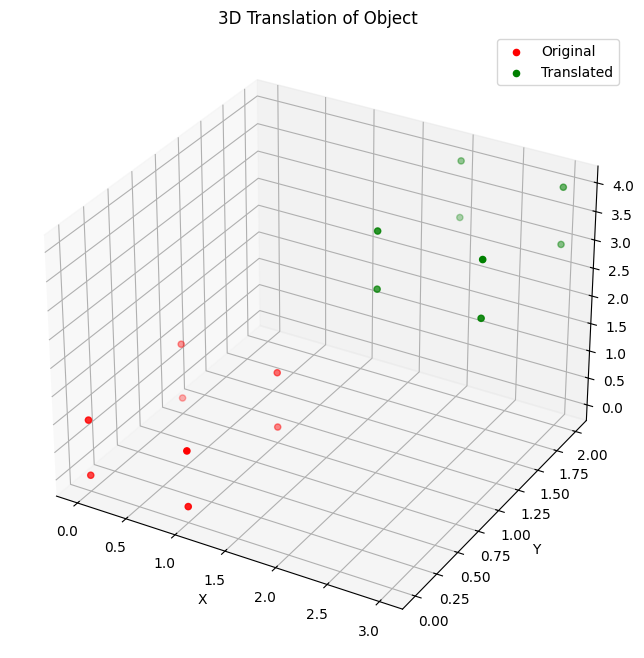

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the 3D cube points
points = np.array([
    [0, 0, 0], [1, 0, 0], [1, 1, 0], [0, 1, 0],  # Bottom face
    [0, 0, 1], [1, 0, 1], [1, 1, 1], [0, 1, 1]   # Top face
])

# Function to translate 3D points
def translate(points, tx, ty, tz):
    # Define the 4x4 translation matrix
    T = np.array([
        [1, 0, 0, tx],
        [0, 1, 0, ty],
        [0, 0, 1, tz],
        [0, 0, 0, 1]
    ])

    # Convert points to homogeneous coordinates
    points_h = np.hstack((points, np.ones((points.shape[0], 1))))

    # Apply translation transformation
    translated_points_h = (T @ points_h.T).T

    # Return only the x, y, z coordinates (remove homogeneous coordinate)
    return translated_points_h[:, :3]

# Translate the cube by 2 units along x, 1 unit along y, and 3 units along z
translated_points = translate(points, 2, 1, 3)

# Plot the original and translated cubes
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot original cube
ax.scatter(points[:, 0], points[:, 1], points[:, 2], color='r', label='Original')

# Plot translated cube
ax.scatter(translated_points[:, 0], translated_points[:, 1], translated_points[:, 2], color='g', label='Translated')

# Add labels and title
ax.set_title("3D Translation of Object")
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()

plt.show()


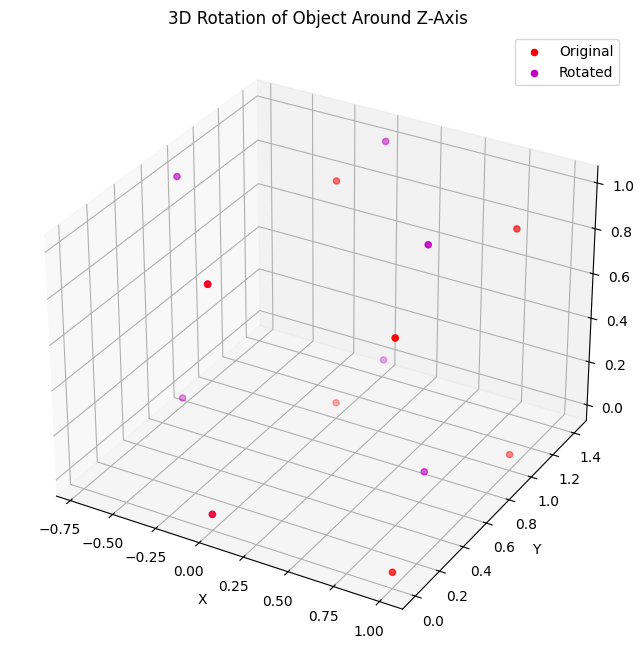

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the 3D cube points
points = np.array([
    [0, 0, 0], [1, 0, 0], [1, 1, 0], [0, 1, 0],  # Bottom face
    [0, 0, 1], [1, 0, 1], [1, 1, 1], [0, 1, 1]   # Top face
])

# Function to rotate 3D points around the z-axis
def rotate_z(points, theta):
    # Define the 4x4 rotation matrix around the z-axis
    R = np.array([
        [np.cos(theta), -np.sin(theta), 0, 0],
        [np.sin(theta), np.cos(theta), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])

    # Convert points to homogeneous coordinates
    points_h = np.hstack((points, np.ones((points.shape[0], 1))))

    # Apply rotation transformation
    rotated_points_h = (R @ points_h.T).T

    # Return only the x, y, z coordinates (remove homogeneous coordinate)
    return rotated_points_h[:, :3]

# Rotate the cube by 45 degrees (π/4 radians) around the z-axis
rotated_points = rotate_z(points, np.pi/4)

# Plot the original and rotated cubes
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot original cube
ax.scatter(points[:, 0], points[:, 1], points[:, 2], color='r', label='Original')

# Plot rotated cube
ax.scatter(rotated_points[:, 0], rotated_points[:, 1], rotated_points[:, 2], color='m', label='Rotated')

# Add labels and title
ax.set_title("3D Rotation of Object Around Z-Axis")
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()

plt.show()
